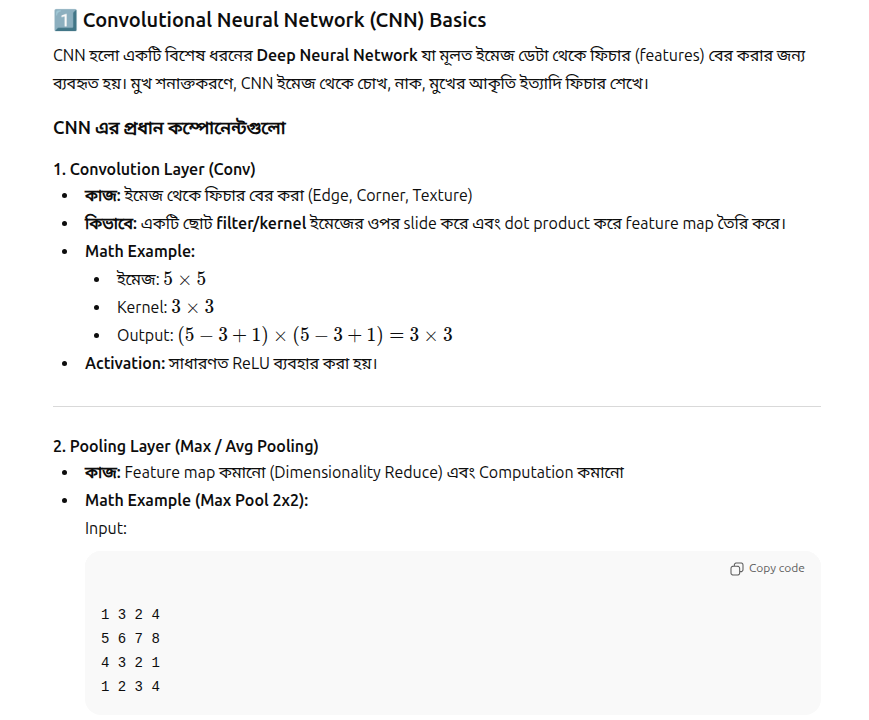

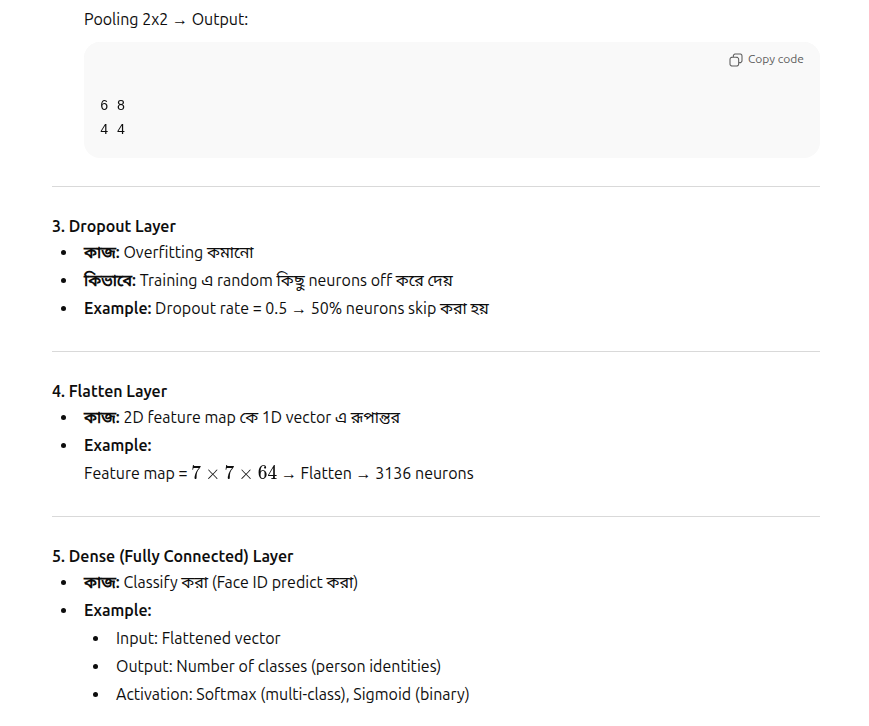

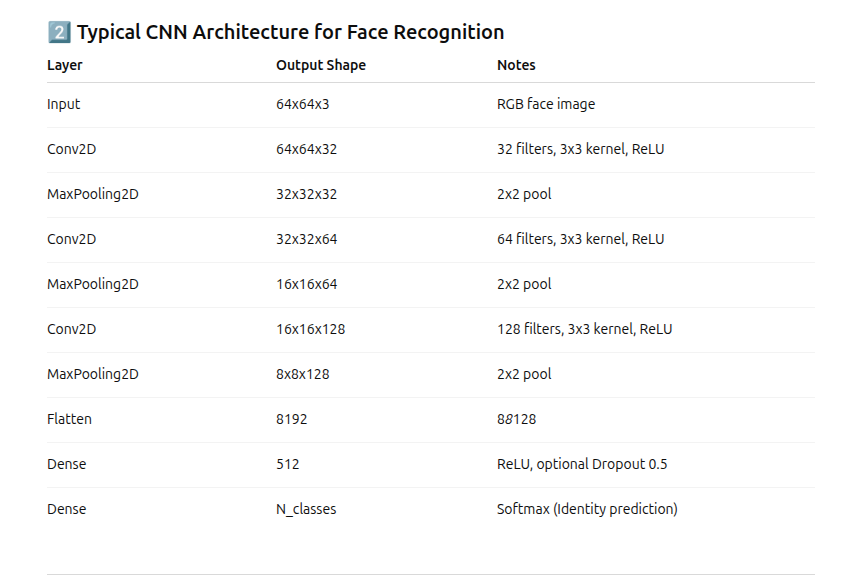

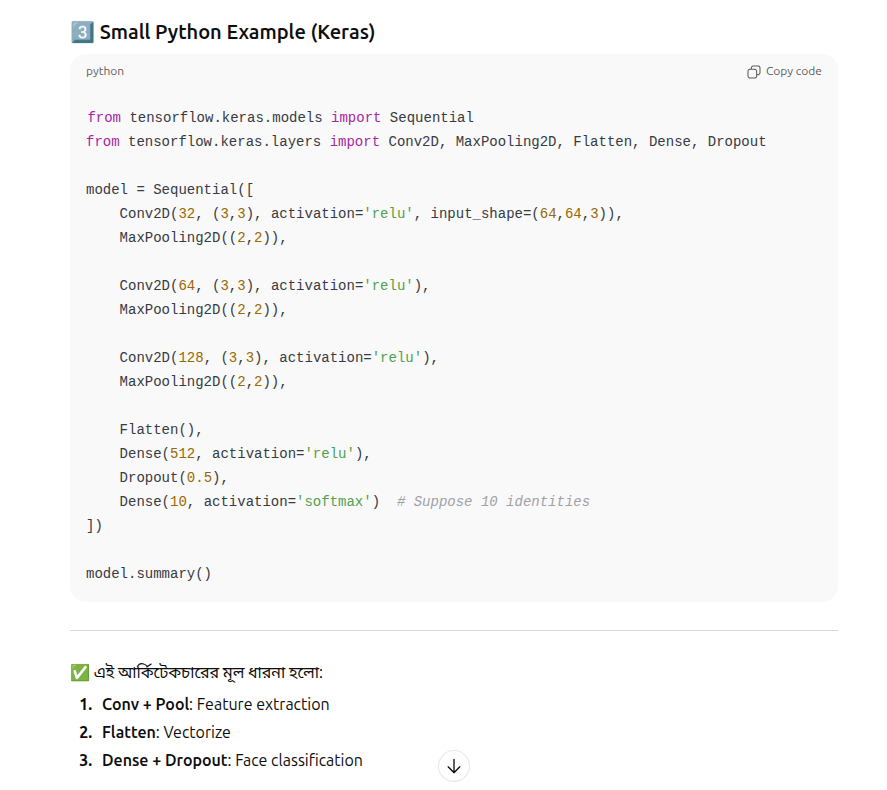

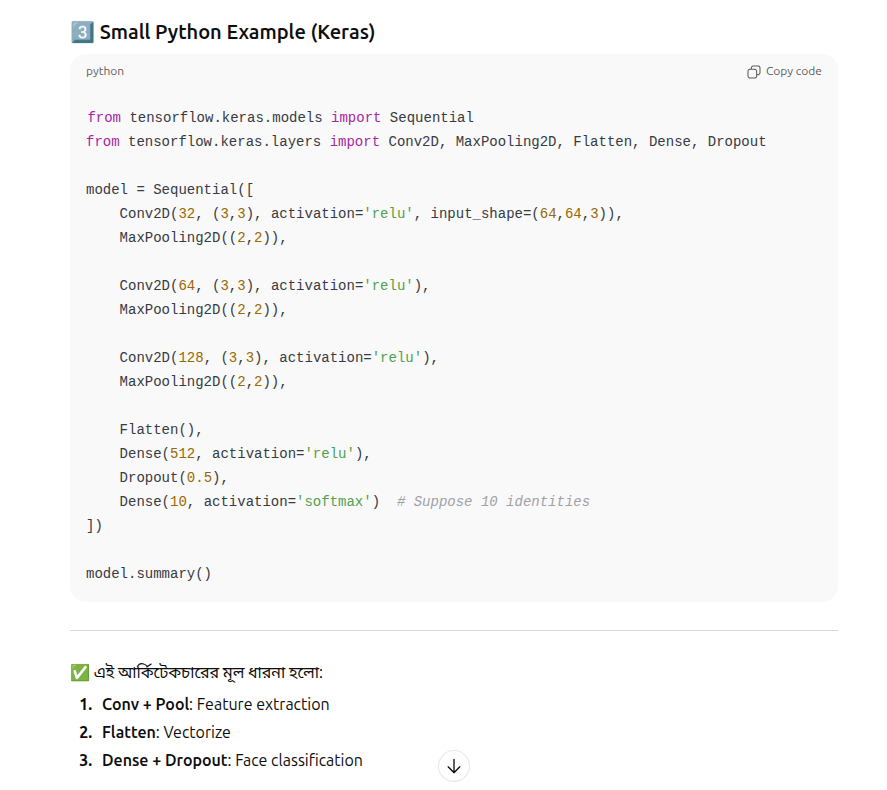

In [4]:
import os
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Dataset Path
train_path = "../dataset/train"
test_path = "../dataset/test"

# Data Augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

# Train & Test Generator
train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(64,64),
    batch_size=32,
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=(64,64),
    batch_size=32,
    class_mode='categorical'
)

# Build CNN Model
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(64,64,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(train_generator.num_classes, activation='softmax')
])

# Compile
model.compile(optimizer=Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Train
model.fit(train_generator, epochs=20, validation_data=test_generator)

# Save model
model.save("custom_cnn_face_recognition.h5")

# Save class mapping
import json
with open("class_indices.json", "w") as f:
    json.dump(train_generator.class_indices, f)


Found 152 images belonging to 30 classes.
Found 6 images belonging to 6 classes.
Epoch 1/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.0306 - loss: 3.4266

ValueError: Arguments `target` and `output` must have the same shape. Received: target.shape=(None, 6), output.shape=(None, 30)